# Step 0: Model Training Script

This script trains machine learning models using historical and operational climate forecast datasets to predict hydrologic components and Net Basin Supply (NBS) across the Great Lakes basin.

## Training Data

Model inputs are derived from:

* **Climate Forecast System Reanalysis (CFSR)** data spanning **1979–2010**
* **Climate Forecast System Analysis (CFSA)** forecast data spanning **2011–2024**

## Target Variables

The machine learning models are trained to predict the following hydrologic components simultaneously across all five Great Lakes:

* Precipitation
* Evaporation
* Runoff
* Net Basin Supply (NBS)

Target datasets include:

* **L2SWBM** for precipitation, evaporation, and runoff
* **Great Lakes Coordinating Committee (GLCC)** datasets for NBS

## Modeling Framework

The workflow combines large-scale climate forecast predictors with observed hydrologic targets to train machine learning models capable of subseasonal-to-annual forecasting across the Great Lakes basin. Simultaneous multi-lake training preserves spatial and temporal relationships between lakes and hydrologic processes.


In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.ensemble import RandomForestClassifier as skRFC
from sklearn.gaussian_process.kernels import WhiteKernel, ConstantKernel, RBF, Matern, RationalQuadratic, ExpSineSquared
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor as skRFR
import xgboost as xgb
import tensorflow as tf
import joblib
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score
from properscoring import crps_ensemble
import matplotlib.pyplot as plt
import sys
import re
import os
import copy

In [12]:
sys.path.append(os.path.abspath('../../'))
from src.data_processor import CFSTransformer
from src.data_loader import DataLoader
from src.data_processor import SeasonalCycleProcessor
from src.database_utils import Database

### Configure Input Paths and Optional Predictors

This cell defines the local repository and input data paths used throughout the workflow. Users should update `local_path` to match the location where the repository was cloned on their system.

Optional predictor datasets, including Great Lakes Surface Temperature (GLSEA SST) and Snow Water Equivalent (SWE), can be enabled or disabled using the `use_sst` and `use_swe` flags (True/False). Corresponding file paths are also specified for loading these datasets into the machine learning feature pipeline.


In [132]:
# ---- Input Paths ---- #

# Local directory where the repository was cloned.
# Update this path to match your local system.
local_path = '/Users/ljob/Desktop/'

# Input directory
input_dir = local_path + 'cnbs-predictor/data/'

# Path to the SFS reforecast database
database = local_path + 'Data/SFS_reforecast/sfs_reforecast_data.db'
table = 'reforecast_data'

## Begin Script

### Feature Construction Workflow

This script prepares the feature dataset for model training by integrating precipitation, evaporation, air temperature, and lake surface temperature data. The workflow is as follows:

#### 1. Read Reanalysis Data from CFSR
- **Precipitation (PCP, mm)**
- **Evaporation (EVAP, mm)** 
- **Air Temperature (TMP, K)** 

#### 2. Assemble Feature Matrix (`X`)
- Construct a DataFrame containing lake- and land-specific values for each Great Lake (Superior, Michigan-Huron, Erie, Ontario).  
- Variables include precipitation, evaporation, and air temperature for both **over-lake** and **over-land** domains.

#### 3. Create Forecast-Like Features
- Apply `CFSProcessor.shift_variables` to generate lead times from **0 to 9 months** for each variable to replicate a 9-month CFS forecast.

#### 4. Include Seasonality and Temporal Features
* Extract the calendar month from the datetime index.
* Encode seasonality using cyclic temporal features:

  * `month_sin`
  * `month_cos`

These cyclical variables preserve the continuous seasonal relationship between months (e.g., December transitions smoothly into January) and avoid artificial discontinuities introduced by one-hot encoding (i.e., month_1 = True).

* Include a continuous `time` feature representing long-term temporal progression to help smooth forecasts and capture gradual trends and low-frequency variability over time.


#### 5. Reorder Features
* Columns are reorganized to ensure a consistent feature ordering for model training and inference:
  1. Temporal features:
     * `time`
     * `month_sin`
     * `month_cos`
  2. Basin-specific predictor variables for:
     * precipitation
     * evaporation
     * air temperature
     across all forecast lead times (`mo0` … `mo9`).


#### 6. Optional Additional Features for Current-State Initialization

Additional predictor variables may optionally be included to provide the machine learning models with information about the current hydrologic and thermal state of the Great Lakes basin.

Optional datasets include:

* **Great Lakes Surface Environmental Analysis (GLSEA)** lake surface temperature (SST) data (`oisst_sst_1981-2024.csv`) in Kelvin
* **Snow Water Equivalent (SWE)** datasets derived from CFSR (`CFSR_SWE_Basin_mm.csv`)

These variables are merged with the reorganized predictor matrix to produce the final feature dataset (`X_merged`). Inclusion of SST and SWE predictors helps improve representation of basin memory, antecedent conditions, and seasonal persistence within the forecasting framework.

#### 7. Feature Table Example

| Feature Category       | Example Feature Names                                                       |
| ---------------------- | --------------------------------------------------------------------------- |
| Temporal Features      | `time`, `month_sin`, `month_cos`                                            |
| SST (Optional)         | `superior_sst`, `michigan-huron_sst`, `erie_sst`, `ontario_sst`             |
| SWE (Optional)         | `superior_swe`, `michigan-huron_swe`, `erie_swe`, `ontario_swe`             |
| Precipitation (Lake)   | `superior_lake_precipitation_mo0` ... `superior_lake_precipitation_mo9`     |
| Precipitation (Land)   | `superior_land_precipitation_mo0` ... `superior_land_precipitation_mo9`     |
| Evaporation (Lake)     | `superior_lake_evaporation_mo0` ... `superior_lake_evaporation_mo9`         |
| Evaporation (Land)     | `superior_land_evaporation_mo0` ... `superior_land_evaporation_mo9`         |
| Air Temperature (Lake) | `superior_lake_air_temperature_mo0` ... `superior_lake_air_temperature_mo9` |
| Air Temperature (Land) | `superior_land_air_temperature_mo0` ... `superior_land_air_temperature_mo9` |


In [158]:
# Split dataset by date ranges into training and testing sets
train_start_date = '1991-01-01'
train_end_date = '2018-12-31'

# Testing dataset
val_start_date = '2019-01-01'
val_end_date = '2022-12-31' #constrained by the L2 dataset

# Training and validation slices
train_slice = slice(train_start_date, train_end_date)
val_slice   = slice(val_start_date, val_end_date)

In [134]:
# Read in data from SFS reforecast database
data = Database(database, table).load()

In [135]:
print(data)

         init_time  member  lead  valid_time      lake surface_type  \
0       1991-03-01       0     0  1991-03-01      erie         lake   
1       1991-03-01       0     0  1991-03-01      erie         lake   
2       1991-03-01       0     0  1991-03-01      erie         lake   
3       1991-03-01       0     0  1991-03-01      erie         land   
4       1991-03-01       0     0  1991-03-01      erie         land   
...            ...     ...   ...         ...       ...          ...   
883867  2025-11-01      10    11  2026-10-01  superior         lake   
883868  2025-11-01      10    11  2026-10-01  superior         lake   
883869  2025-11-01      10    11  2026-10-01  superior         land   
883870  2025-11-01      10    11  2026-10-01  superior         land   
883871  2025-11-01      10    11  2026-10-01  superior         land   

               component       value  
0        air_temperature  274.068451  
1       latent_heat_flux    5.852441  
2          precipitation  122.

In [136]:
data["column_name"] = (
            data["lake"] + "_" +
            data["surface_type"] + "_" +
            data["component"] + "_mo" +
            data["lead"].astype(str)
        )
data["init_time"] = pd.to_datetime(data["init_time"])

# --- Pivot safely ---
df_wide = data.pivot_table(
    index=["init_time", "member"],
    columns="column_name",
    values="value",
    aggfunc="first"
)

df_wide.columns.name = None

# --- Enforce required deterministic ordering ---
feature_column_order = [
    f"{lake}_{surface_type}_{comp}_mo{m}"
    for lake in ["superior", "michigan-huron", "erie", "ontario"]
    for surface_type in ["lake", "land"]
    for comp in ["precipitation", "latent_heat_flux", "air_temperature"]
    for m in range(12)
]

df_wide = df_wide.reindex(columns=feature_column_order)

# --- Drop rows with missing required features AFTER alignment ---
df_final = df_wide.dropna()

print(df_wide)

                   superior_lake_precipitation_mo0  \
init_time  member                                    
1991-03-01 0                             42.045650   
           1                             69.243921   
           2                             35.314127   
           3                             72.888006   
           4                            114.442315   
...                                            ...   
2025-11-01 6                             49.262075   
           7                             96.447918   
           8                             52.259653   
           9                             50.323992   
           10                            90.155012   

                   superior_lake_precipitation_mo1  \
init_time  member                                    
1991-03-01 0                             49.305089   
           1                             77.137880   
           2                            113.914582   
           3               

In [ ]:
#print(df_wide[df_wide["superior_lake_air_temperature_mo5"].isna()])

In [137]:
feature_column_order = [
            f"{lake}_{surface_type}_{comp}_mo{m}"
            for lake in ["superior", "michigan-huron", "erie", "ontario"]
            for surface_type in ["lake", "land"]
            for comp in ["precipitation", "latent_heat_flux", "air_temperature"]
            for m in range(12)
        ]

# --- Ensure columns are in the correct order ---
df_wide_reordered = df_wide.reindex(columns=feature_column_order)

# Set the index by date
#X = X.set_index(pd.to_datetime(X['date'])).drop(columns='date')

In [138]:
print(df_wide_reordered)

                   superior_lake_precipitation_mo0  \
init_time  member                                    
1991-03-01 0                             42.045650   
           1                             69.243921   
           2                             35.314127   
           3                             72.888006   
           4                            114.442315   
...                                            ...   
2025-11-01 6                             49.262075   
           7                             96.447918   
           8                             52.259653   
           9                             50.323992   
           10                            90.155012   

                   superior_lake_precipitation_mo1  \
init_time  member                                    
1991-03-01 0                             49.305089   
           1                             77.137880   
           2                            113.914582   
           3               

### Remove the Seasonal Cycle and Calculate Anomalies

This step calculates the climatological seasonal cycle for each predictor variable using the training-period data only. Monthly means are computed for every variable to represent the expected seasonal baseline conditions.

The fitted seasonal climatology is then saved for reproducibility and future inference workflows. After fitting, the seasonal cycle is removed from the full dataset to generate anomaly-based predictors (`X_anom`).

Using anomalies instead of absolute values helps reduce strong seasonal dominance in the predictors and allows the machine learning models to better learn departures from typical conditions, including interannual variability and extreme hydrologic events.


In [139]:
X = df_wide_reordered.copy()

# Fit seasonal cycle
scp_X = SeasonalCycleProcessor().fit(
    X,
    var_list=list(X.columns),
    baseline_time=train_slice,
    baseline_definition={
        "train_start" : train_start_date,
        "train_end" : train_end_date
    }
)

# Save the fitted seasonal cycle processor for later use
paths = scp_X.save(input_dir + "input/climatology/inputs")

# Transform the full dataset
X_anom = scp_X.transform(X)

       superior_lake_precipitation_mo0  superior_lake_precipitation_mo1  \
month                                                                     
1                                  NaN                              NaN   
2                                  NaN                              NaN   
3                            67.812900                        83.790209   
4                            80.014082                        84.272626   
5                            86.538674                        95.237523   
6                            86.629294                        82.664908   
7                            84.627086                        85.728633   
8                            80.498412                        92.273653   
9                            83.383890                        79.948610   
10                                 NaN                              NaN   
11                           72.097257                        66.017078   
12                       

### Verify Native and Anomaly Predictor Data

This diagnostic plot compares the original predictor time series with its anomaly-transformed counterpart after seasonal cycle removal.

The raw series (`X`) represents the native predictor values, while the anomaly series (`X_anom`) represents departures from the climatological monthly mean. This visualization provides a simple quality-control check to confirm that the seasonal cycle was successfully removed while preserving interannual variability and anomalous events.


ConversionError: Failed to convert value(s) to axis units: array([(Timestamp('1991-03-01 00:00:00'), 0),
       (Timestamp('1991-03-01 00:00:00'), 1),
       (Timestamp('1991-03-01 00:00:00'), 2), ...,
       (Timestamp('2025-11-01 00:00:00'), 8),
       (Timestamp('2025-11-01 00:00:00'), 9),
       (Timestamp('2025-11-01 00:00:00'), 10)],
      shape=(3069,), dtype=object)

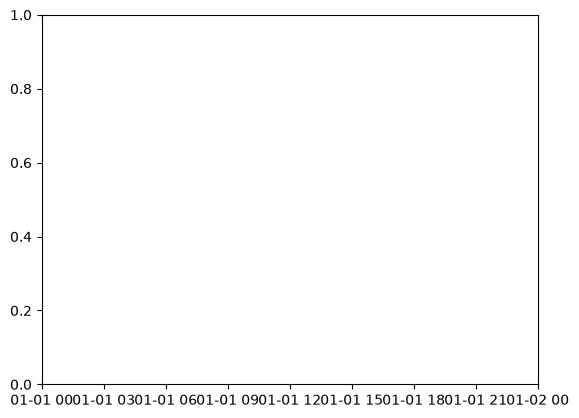

In [15]:
var = "superior_lake_precipitation_mo4"

plt.figure()
plt.plot(X[var], label="raw")
plt.plot(X_anom[var], label="anomaly")
plt.legend()
plt.title(var)
plt.show()

### Add Temporal Features and Reorder Predictors

This step adds temporal features to the predictor matrix, including `time`, `month_sin`, and `month_cos`. These variables help the model represent long-term temporal progression and smooth seasonal variability across months.

The feature columns are then reorganized into a consistent order for model training and inference. Optional current-state predictors, including SST and SWE, are only included if they were enabled in the user configuration.

In [140]:
# Add time, month_sin, and month_cos features
X_time = CFSTransformer(X_anom).add_time_features()

# Always include temporal features first
feature_column_order = [
    'time',
    'month_sin',
    'month_cos'
]

# Add lead-time CFS predictor variables
feature_column_order += [
    f'{lake}_{surface_type}_{comp}_mo{m}'
    for lake in ['superior', 'michigan-huron', 'erie', 'ontario']
    for surface_type in ['lake', 'land']
    for comp in ['precipitation', 'latent_heat_flux', 'air_temperature']
    for m in range(10)
]

# Keep only columns that exist in X_time.
# This makes the workflow robust if optional features are disabled.
feature_column_order = [
    col for col in feature_column_order
    if col in X_time.columns
]

X_reorg = X_time[feature_column_order]

In [141]:
print(X_reorg)

                       time  month_sin     month_cos  \
init_time  member                                      
1991-03-01 0      -1.712228        1.0  6.123234e-17   
           1      -1.712228        1.0  6.123234e-17   
           2      -1.712228        1.0  6.123234e-17   
           3      -1.712228        1.0  6.123234e-17   
           4      -1.712228        1.0  6.123234e-17   
...                     ...        ...           ...   
2025-11-01 6       1.730321       -0.5  8.660254e-01   
           7       1.730321       -0.5  8.660254e-01   
           8       1.730321       -0.5  8.660254e-01   
           9       1.730321       -0.5  8.660254e-01   
           10      1.730321       -0.5  8.660254e-01   

                   superior_lake_precipitation_mo0  \
init_time  member                                    
1991-03-01 0                            -25.767250   
           1                              1.431021   
           2                            -32.498773   
 

## Target Construction Workflow

This script prepares the target dataset for model training, including precipitation, evaporation, runoff, and net basin supply (NBS) for each Great Lake. The workflow is as follows:

### 1. Load L2SWBM Data
- Source: [L2SWBM dataset](https://zenodo.org/records/13883098)  
- Required file format for each lake (erie, miHuron, ontario, superior):  
  - Evaporation: `{lake}Evap_MonthlyRun.csv`  
  - Precipitation: `{lake}Precip_MonthlyRun.csv`  
  - Runoff: `{lake}Runoff_MonthlyRun.csv`  
- Each loader function formats the data into a pandas DataFrame with a **datetime index**.  
- Columns are named `{lake}_{component}_obs` (e.g., `erie_precipitation_obs`) for each lake and component.

### 2. Load GLCC Data
- Source: Great Lakes Coordinating Committee (GLCC)  
- Required file format for each lake (Erie, MichiganHuron, Ontario, Superior):  
  - `Lake{lake}_MonthlyNetBasinSupply_1900to2025.csv`  
- Loader function formats the data into a pandas DataFrame with a **datetime index**.  
- Columns are named `lake_nbs_obs` for each lake.

### 3. Assemble Target Matrix (`targets`)
- Combine L2SWBM components (precipitation, evaporation, runoff) with GLCC NBS for each lake into a single DataFrame.  
- Column naming convention: `{lake}_target_{component}` (e.g., `superior_target_evaporation`).  
- Only keep rows where **all target values are available** by dropping any rows with missing data.

### 4. Create Forecast-Like Lead Variables
- Apply `CFSProcessor.shift_variables` to generate **lead versions of all targets**, to minic the targeted **12-month forecast horizon** (lead times 0–11).

### 5. Reorder Target Columns
- Columns are organized to ensure a consistent structure for modeling:  

```text
superior_target_precipitation_mo0 … mo11
superior_target_evaporation_mo0 … mo11
superior_target_runoff_mo0 … mo11
superior_target_nbs_mo0 … mo11
michigan-huron_target_precipitation_mo0 … mo11
michigan-huron_target_evaporation_mo0 … mo11
...
ontario_target_nbs_mo0 … mo11


In [142]:
dataloader = DataLoader()

In [143]:
# Load L2SWBM data
l2 = dataloader.l2swbm(input_dir + 'l2swbm/')

# Load GLCC data
glcc = dataloader.glcc(input_dir + 'glcc/', units='mm')

# Targets are the components (P, E, R) fro L2SWBM and NBS from GLCC
targets = pd.DataFrame({
    'superior_target_evaporation': l2['superior_evaporation_obs'],
    'superior_target_precipitation': l2['superior_precipitation_obs'],
    'superior_target_runoff': l2['superior_runoff_obs'],
    'superior_target_nbs': glcc['superior_nbs_obs'],
    'michigan-huron_target_evaporation': l2['michigan-huron_evaporation_obs'],
    'michigan-huron_target_precipitation': l2['michigan-huron_precipitation_obs'],
    'michigan-huron_target_runoff': l2['michigan-huron_runoff_obs'],
    'michigan-huron_target_nbs': glcc['michigan-huron_nbs_obs'],
    'erie_target_evaporation': l2['erie_evaporation_obs'],
    'erie_target_precipitation': l2['erie_precipitation_obs'],
    'erie_target_runoff': l2['erie_runoff_obs'],
    'erie_target_nbs': glcc['erie_nbs_obs'],
    'ontario_target_evaporation': l2['ontario_evaporation_obs'],
    'ontario_target_precipitation': l2['ontario_precipitation_obs'],
    'ontario_target_runoff': l2['ontario_runoff_obs'],
    'ontario_target_nbs': glcc['ontario_nbs_obs']
})

# The dataframes are merged by date so we need to drop rows with NaN values
# This ensures that we only keep rows where all target values are available
targets = targets.dropna()

#targets_shifted = CFSTransformer(targets).shift_variables(lag=0, lead=12)

### Remove the Seasonal Cycle from Target Variables

This step calculates the climatological seasonal cycle for the target variables using the training-period data only in order to avoid data leakage into the validation and forecast periods.

Monthly climatological means are calculated for each target variable and used to define the expected seasonal baseline conditions. The fitted climatology is then removed from the full target dataset to generate anomaly-based target variables (`targets_anom`).

The resulting climatology artifacts are saved to disk so the identical seasonal baseline can be applied consistently during operational forecasting and inverse transformation back to native units.

In [144]:
targets['place_holder'] = 0.0
targets = targets.reset_index()

targets = targets.rename(
    columns={
        "date": "init_time"
    }
)
targets = targets.set_index(["init_time", "place_holder"])

print(targets)

                         superior_target_evaporation  \
init_time  place_holder                                
1950-01-01 0.0                            125.357918   
1950-02-01 0.0                             70.413371   
1950-03-01 0.0                             42.505142   
1950-04-01 0.0                             25.310708   
1950-05-01 0.0                             -8.965747   
...                                              ...   
2022-08-01 0.0                              5.267900   
2022-09-01 0.0                             50.655000   
2022-10-01 0.0                             81.158000   
2022-11-01 0.0                             95.479000   
2022-12-01 0.0                            124.970000   

                         superior_target_precipitation  \
init_time  place_holder                                  
1950-01-01 0.0                                   88.75   
1950-02-01 0.0                                   36.98   
1950-03-01 0.0                         

In [145]:
# 1) Fit monthly climatology on TRAIN ONLY (avoid leakage)
scp_y = SeasonalCycleProcessor().fit(
    targets,
    var_list=list(targets.columns),          # explicit is good here
    baseline_time=train_slice,
    baseline_definition={
        "train_start": train_start_date,
        "train_end": train_end_date,
        "note": "targets climatology fit on training period only"
    },
)

# 2) Transform full targets to anomalies
targets_anom = scp_y.transform(targets)

# Save artifact so forecast notebook can load the same baseline
paths = scp_y.save(input_dir + "input/climatology/targets")

       superior_target_evaporation  superior_target_precipitation  \
month                                                               
1                       103.712806                      52.461935   
2                        58.759806                      37.341290   
3                        42.394290                      43.115806   
4                        16.191813                      60.341613   
5                         2.440335                      69.719355   
6                        -4.107719                      79.170323   
7                        -2.293677                      79.117097   
8                        17.227127                      75.356452   
9                        53.091258                      82.623548   
10                       72.131484                      73.686452   
11                      100.069677                      61.410968   
12                      114.669387                      58.673871   

       superior_target_runoff  su

### Verify Native and Anomaly Target Data

This diagnostic plot compares the original target variable time series with its anomaly-transformed counterpart after seasonal cycle removal.

The raw target series (`targets`) represents the native hydrologic values, while the anomaly series (`targets_anom`) represents departures from the climatological monthly mean calculated from the training period. This visualization serves as a quality-control check to confirm that the seasonal cycle was successfully removed while preserving interannual variability and anomalous hydrologic events.

ConversionError: Failed to convert value(s) to axis units: array([(Timestamp('1950-01-01 00:00:00'), 0.0),
       (Timestamp('1950-02-01 00:00:00'), 0.0),
       (Timestamp('1950-03-01 00:00:00'), 0.0),
       (Timestamp('1950-04-01 00:00:00'), 0.0),
       (Timestamp('1950-05-01 00:00:00'), 0.0),
       (Timestamp('1950-06-01 00:00:00'), 0.0),
       (Timestamp('1950-07-01 00:00:00'), 0.0),
       (Timestamp('1950-08-01 00:00:00'), 0.0),
       (Timestamp('1950-09-01 00:00:00'), 0.0),
       (Timestamp('1950-10-01 00:00:00'), 0.0),
       (Timestamp('1950-11-01 00:00:00'), 0.0),
       (Timestamp('1950-12-01 00:00:00'), 0.0),
       (Timestamp('1951-01-01 00:00:00'), 0.0),
       (Timestamp('1951-02-01 00:00:00'), 0.0),
       (Timestamp('1951-03-01 00:00:00'), 0.0),
       (Timestamp('1951-04-01 00:00:00'), 0.0),
       (Timestamp('1951-05-01 00:00:00'), 0.0),
       (Timestamp('1951-06-01 00:00:00'), 0.0),
       (Timestamp('1951-07-01 00:00:00'), 0.0),
       (Timestamp('1951-08-01

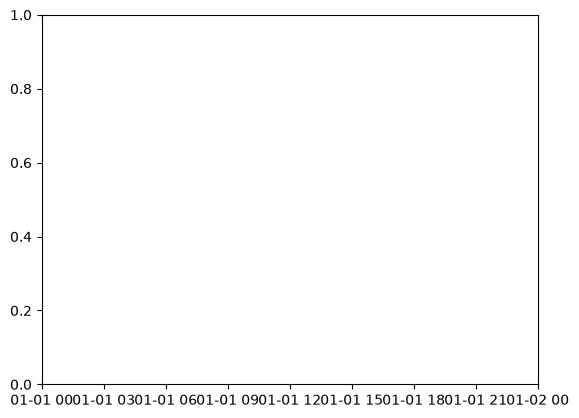

In [80]:
import matplotlib.pyplot as plt

var = "superior_target_evaporation"
plt.figure()
plt.plot(targets[var], label="raw")
plt.plot(targets_anom[var], label="anomaly")
plt.legend()
plt.title(var)
plt.show()

### Create Lead-Time Target Variables

This step converts the anomaly-based target variables into lead-time forecast targets spanning 12 months ahead.

Target variables are shifted to create forecast lead times from `mo0` through `mo11`, representing the full 12-month prediction horizon for each lake and hydrologic component. The resulting target columns are then reorganized into a consistent ordering to ensure compatibility with machine learning training, validation, and forecasting workflows.


In [146]:
# Shift the targets to create lead variables
targets_lead = CFSTransformer(targets_anom).shift_variables(lag=0, lead=12)

# Define the target column order for the 12-month forecast
target_column_order =[
        f'{lake}_target_{comp}_mo{m}'
        for lake in ['superior', 'michigan-huron', 'erie', 'ontario']
        for comp in ['precipitation', 'evaporation', 'runoff', 'nbs']
        for m in range(12) #from 0 to 11, representing the 12 month forecast
        ]

# Reorganize the targets DataFrame to match the target column order
targets_reorg = targets_lead.reindex(columns=target_column_order)

## Align Features and Targets

This step ensures that the **features** and **target** datasets are aligned:  

### 1. Subset the reorganized target DataFrame (`targets_reorg`) to only include rows corresponding to the **dates present in the merged feature dataset** (`X_merged`).  
   - This guarantees that each row of features has a matching target for model training.  
   - The aligned target dataset is stored in `aligned_y`.

### 2. Print summary information for verification:  
   - **Number of features** (`X_merged.shape[1]`)  
   - **Number of target variables** (`aligned_y.shape[1]`)  

This alignment is crucial for ensuring consistent input-output pairing before training or forecasting.


In [147]:
X_drop = X_reorg.reset_index("member", drop=True)
targets_drop = targets_reorg.reset_index("place_holder", drop=True)

In [148]:
X_drop = X_drop.dropna()

if X_drop.isna().any().any():
    print("NaNs found in X_drop:")
    print(X_drop.isna().sum()[X_drop.isna().sum() > 0])

In [149]:
# Make sure the features and target indices/dates align
aligned_X, aligned_y = X_drop.align(targets_drop, join='inner', axis=0)

print(f'Number of Features: {aligned_X.shape[1]}')
print(f'Number of Targets: {aligned_y.shape[1]}')

Number of Features: 243
Number of Targets: 192


In [151]:
print(aligned_X)

                time  month_sin     month_cos  \
init_time                                       
1991-03-01 -1.712228        1.0  6.123234e-17   
1991-03-01 -1.712228        1.0  6.123234e-17   
1991-03-01 -1.712228        1.0  6.123234e-17   
1991-03-01 -1.712228        1.0  6.123234e-17   
1991-03-01 -1.712228        1.0  6.123234e-17   
...              ...        ...           ...   
2021-11-01  1.333104       -0.5  8.660254e-01   
2021-11-01  1.333104       -0.5  8.660254e-01   
2021-11-01  1.333104       -0.5  8.660254e-01   
2021-11-01  1.333104       -0.5  8.660254e-01   
2021-11-01  1.333104       -0.5  8.660254e-01   

            superior_lake_precipitation_mo0  superior_lake_precipitation_mo1  \
init_time                                                                      
1991-03-01                       -25.767250                       -34.485120   
1991-03-01                         1.431021                        -6.652329   
1991-03-01                       -32.49877

## Train-Test Split by Date

This step divides the dataset into **training** and **testing** subsets based on date ranges, rather than random sampling, to **preserve seasonal and temporal structure**:  

### 1. **Training Set (≈80% of data)**  
   - Start: January 1982  
   - End: December 2005  
   - `X_train` and `y_train` contain features and targets within this range.  

### 2. **Testing/Validation Set (≈20% of data)**  
   - Start: January 2006  
   - End: January 2011  
   - `X_test` and `y_test` contain features and targets within this range.  

This chronological split ensures that the model is evaluated on **future data**, maintaining realistic forecasting conditions and seasonal patterns.


In [159]:
X_train = aligned_X[train_start_date:train_end_date]
y_train = aligned_y[train_start_date:train_end_date]
X_test = aligned_X[val_start_date:val_end_date]
y_test = aligned_y[val_start_date:val_end_date]

In [161]:
print(X_test)

                time  month_sin     month_cos  \
init_time                                       
2019-03-01  1.068292        1.0  6.123234e-17   
2019-03-01  1.068292        1.0  6.123234e-17   
2019-03-01  1.068292        1.0  6.123234e-17   
2019-03-01  1.068292        1.0  6.123234e-17   
2019-03-01  1.068292        1.0  6.123234e-17   
...              ...        ...           ...   
2021-11-01  1.333104       -0.5  8.660254e-01   
2021-11-01  1.333104       -0.5  8.660254e-01   
2021-11-01  1.333104       -0.5  8.660254e-01   
2021-11-01  1.333104       -0.5  8.660254e-01   
2021-11-01  1.333104       -0.5  8.660254e-01   

            superior_lake_precipitation_mo0  superior_lake_precipitation_mo1  \
init_time                                                                      
2019-03-01                        -7.955549                        18.587351   
2019-03-01                        12.937785                        24.884308   
2019-03-01                        -5.73906

## Feature and Target Standardization

This step standardizes the features and targets to improve model training and convergence:  

### 1. **Define Scalers**  
   - `x_scaler` and `y_scaler` are instances of `StandardScaler` from `scikit-learn`.  

### 2. **Fit and Transform Training Data**  
   - The scalers are **fit only on the training data** to avoid data leakage.  
   - `X_train_scaled` and `y_train_scaled` contain standardized training features and targets.  

### 3. **Transform Testing Data**  
   - Apply the same fitted scalers to the testing data (`X_test_scaled` and `y_test_scaled`) to ensure consistent scaling.  

### 4. **Save Scalers for Future Use**  
   - The fitted scalers are saved using `joblib.dump` so they can be applied during the **prediction phase** on new data, maintaining the same scaling.


In [162]:
# Define the scaler we want to use
x_scaler = StandardScaler()
y_scaler = StandardScaler()

# Standardize the data
# This will scale the features and targets between 0 and 1
# It is important to fit the scaler on the training data and then transform both train and test data
X_train_scaled = x_scaler.fit_transform(X_train)
X_test_scaled = x_scaler.transform(X_test)
y_train_scaled = y_scaler.fit_transform(y_train)
y_test_scaled = y_scaler.transform(y_test)

# Save the scalers to use later during the prediction phase
joblib.dump(x_scaler, input_dir + 'input/scalers/x_scaler_anom.joblib')
joblib.dump(y_scaler, input_dir + 'input/scalers/y_scaler_anom.joblib')

['/Users/ljob/Desktop/cnbs-predictor/data/input/scalers/y_scaler_anom.joblib']

In [163]:
# ------------------------------------------------------------
# Check for NaNs before scaling
# ------------------------------------------------------------

if X_train.isna().any().any():
    print("NaNs found in X_train:")
    print(X_train.isna().sum()[X_train.isna().sum() > 0])

if X_test.isna().any().any():
    print("NaNs found in X_test:")
    print(X_test.isna().sum()[X_test.isna().sum() > 0])

if y_train.isna().any().any():
    print("NaNs found in y_train:")
    print(y_train.isna().sum()[y_train.isna().sum() > 0])

if y_test.isna().any().any():
    print("NaNs found in y_test:")
    print(y_test.isna().sum()[y_test.isna().sum() > 0])


# ------------------------------------------------------------
# Stop if any NaNs are present
# ------------------------------------------------------------

if (
    X_train.isna().any().any()
    or X_test.isna().any().any()
    or y_train.isna().any().any()
    or y_test.isna().any().any()
):
    raise ValueError(
        "NaNs detected in training or testing data. "
        "Resolve missing values before scaling and training."
    )


# ------------------------------------------------------------
# Define scalers
# ------------------------------------------------------------

x_scaler = StandardScaler()
y_scaler = StandardScaler()


# ------------------------------------------------------------
# Scale data
# ------------------------------------------------------------

X_train_scaled = x_scaler.fit_transform(X_train)
X_test_scaled = x_scaler.transform(X_test)

y_train_scaled = y_scaler.fit_transform(y_train)
y_test_scaled = y_scaler.transform(y_test)


# ------------------------------------------------------------
# Convert back to DataFrames
# Preserve index and column names
# ------------------------------------------------------------

X_train_scaled = pd.DataFrame(
    X_train_scaled,
    index=X_train.index,
    columns=X_train.columns
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    index=X_test.index,
    columns=X_test.columns
)

y_train_scaled = pd.DataFrame(
    y_train_scaled,
    index=y_train.index,
    columns=y_train.columns
)

y_test_scaled = pd.DataFrame(
    y_test_scaled,
    index=y_test.index,
    columns=y_test.columns
)

## Gaussian Process Regression (GPR) Model Setup, Training and Evaluation

This step defines, trains, and evaluates a **Gaussian Process Regression (GPR)** model using the preprocessed features and targets.  

### 1. Kernel Selection
- Several kernel options are explored for modeling:  
  - **Basic kernel:** `ConstantKernel * RBF`  
  - **Matt's optimal kernel:** `1.0 * Matern(nu=1.5) * RationalQuadratic()` (currently used)  
  - Optional seasonal components: `ExpSineSquared` for modeling periodicity, or combinations of `RBF`, `Matern`, and `RationalQuadratic`.  

### 2. Model Definition
- Initialize the GPR model with the selected kernel.  
- Parameters:  
  - `alpha=0.1` → observation noise level  
  - `n_restarts_optimizer=10` → number of restarts for kernel hyperparameter optimization  
  - `random_state=42` → ensures reproducibility  

### 3. Model Training
- Fit the GPR model on the **scaled training data** (`X_train_scaled` and `y_train_scaled`).  
- Save the trained model using `joblib` for future use.

### 4. Predictions and Evaluation
- Predict on the **scaled testing features** (`X_test_scaled`) and obtain uncertainty estimates (`sigma`).  
- Compute **R² score** on the testing data to evaluate model performance:  
  ```python
  r2 = r2_score(y_test_scaled, y_pred_GP)

(The function below should be added to the data processor)

In [164]:
print(X_train_scaled)

                time  month_sin  month_cos  superior_lake_precipitation_mo0  \
init_time                                                                     
1991-03-01 -1.709432   1.463835   0.613818                        -0.866785   
1991-03-01 -1.709432   1.463835   0.613818                         0.050773   
1991-03-01 -1.709432   1.463835   0.613818                        -1.093879   
1991-03-01 -1.709432   1.463835   0.613818                         0.173710   
1991-03-01 -1.709432   1.463835   0.613818                         1.575583   
...              ...        ...        ...                              ...   
2018-11-01  1.715790  -0.602023   2.097873                         0.452057   
2018-11-01  1.715790  -0.602023   2.097873                         0.256203   
2018-11-01  1.715790  -0.602023   2.097873                         0.617080   
2018-11-01  1.715790  -0.602023   2.097873                        -0.132588   
2018-11-01  1.715790  -0.602023   2.097873          

In [165]:
# Testing Different Kernels
# Basic kernel using ConstantKernel:
#kernel = ConstantKernel(1.0, (1e-3, 1e3)) * RBF(1.0, (1e-2, 1e2))

# Matt's optimal kernel: 
kernel = 1.0 * Matern(nu=1.5) * RationalQuadratic()

#kernel = 1.0 * Matern(length_scale=50.0, nu=1.5, length_scale_bounds=(1e-10, 1e3)) \
#         * RationalQuadratic(alpha=0.0001, length_scale=.01, length_scale_bounds=(1e-10, 1e3))

# Test to add a seasonality component:
#period = 3.0  # Period of the season
#kernel = ConstantKernel(1.0, (1e-3, 1e3)) * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2)) + ExpSineSquared(length_scale=1.0, periodicity=period, periodicity_bounds=(1e-2, 1e2))

# Set up the model
gpr = GaussianProcessRegressor(kernel=kernel, alpha=0.1, n_restarts_optimizer=10, random_state=42)

# Fit the model
gpr.fit(X_train_scaled, y_train_scaled)

# Save the trained model
joblib.dump(gpr, input_dir + 'input/models/GP_trained_model_anom.joblib')

# Predictions
y_pred_GP, sigma = gpr.predict(X_test_scaled, return_std=True)

# Evaluate the model
r2 = r2_score(y_test_scaled, y_pred_GP)

print(f"R² Score: {r2:.4f}")
# Optimized kernel after training
print("Optimized Kernel:", gpr.kernel_)

# Kernel hyperparameters
print("Kernel Hyperparameters:", gpr.kernel_.theta)

KeyboardInterrupt: 

In [84]:
def add_climatology_back_leadwide(
        df_anom_leadwide: pd.DataFrame,
        scp_y: "SeasonalCycleProcessor",
        strict: bool = False,
    ) -> pd.DataFrame:
        """
        Convert lead-wide anomaly targets to lead-wide absolute targets by adding a monthly climatology.

        Parameters
        ----------
        df_anom_leadwide : pd.DataFrame
            Anomaly DataFrame indexed by init date (must be a DatetimeIndex).
        scp_y : SeasonalCycleProcessor
            A fitted seasonal-cycle processor.
        strict : bool
            If True, raise error if column does not match `_mo{k}`.

        Returns
        -------
        pd.DataFrame
            Same shape/columns/index as `df_anom_leadwide`, but in absolute units.
        """
        if not isinstance(df_anom_leadwide.index, pd.DatetimeIndex):
            raise ValueError("df_anom_leadwide must have a DatetimeIndex (init dates).")

        if not hasattr(scp_y, "climatology"):
            raise AttributeError("scp_y must have a `climatology` attribute (fit the processor first).")

        clim = scp_y.climatology
        out = df_anom_leadwide.copy()
        idx = out.index

        for col in out.columns:
            m = SeasonalCycleProcessor._MO_RE.search(col)
            if m is None:
                if strict:
                    raise ValueError(f"Column '{col}' does not end with _mo{{k}}.")
                continue
            lead = int(m.group(1))
            base = SeasonalCycleProcessor._MO_RE.sub("", col)
            if base not in clim.columns:
                raise KeyError(f"Base variable '{base}' not found in climatology columns.")
            verifying_month = (idx + pd.DateOffset(months=lead)).month
            out[col] = out[col].to_numpy() + clim.loc[verifying_month, base].to_numpy()
        return out

In [86]:
def unscale_to_df(y_std, scaler, index, columns):
    return pd.DataFrame(scaler.inverse_transform(y_std), index=index, columns=columns)

def r2_flat(a, b):
    return r2_score(a.to_numpy().ravel(), b.to_numpy().ravel())

# 1) standardized -> anomaly units (lead-wide columns already present)
y_true_anom = unscale_to_df(y_test_scaled, y_scaler, y_test.index, y_test.columns)
y_pred_anom = unscale_to_df(y_pred_GP,    y_scaler, y_test.index, y_test.columns)

print("R² (anomaly, lead-wide):", r2_flat(y_true_anom, y_pred_anom))

# 2) anomaly -> absolute (lead-aware)
#y_true_abs = SeasonalCycleProcessor().add_climatology_back_leadwide(y_true_anom, scp_y)
#y_pred_abs = SeasonalCycleProcessor().add_climatology_back_leadwide(y_pred_anom, scp_y)
y_true_abs = add_climatology_back_leadwide(y_true_anom, scp_y)
y_pred_abs = add_climatology_back_leadwide(y_pred_anom, scp_y)

print("R² (absolute, reconstructed):", r2_flat(y_true_abs, y_pred_abs))

# 3) climatology-only baseline in absolute space (lead-aware!)
y_clim_abs = SeasonalCycleProcessor().add_climatology_back_leadwide(y_true_anom * 0.0, scp_y)
print("R² (absolute, climatology-only):", r2_flat(y_true_abs, y_clim_abs))

R² (anomaly, lead-wide): -0.038330754125370126
R² (absolute, reconstructed): 0.6170190592658888
R² (absolute, climatology-only): 0.6306104727331849


In [166]:
import xgboost as xgb

# Create the XGBoost regressor 
xgb = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    objective='reg:squarederror'  # for regression
)

# Train the model
xgb.fit(X_train_scaled, y_train_scaled)

# Predict on the test set
y_pred_XGB = xgb.predict(X_test_scaled)

# Save the trained model
joblib.dump(xgb, input_dir + 'input/models/XGB_trained_model_anom.joblib')

# Evaluate the model
r2 = r2_score(y_test_scaled, y_pred_XGB)

print(f"R² Score: {r2:.4f}")

R² Score: -0.8278


In [167]:
# 1) standardized -> anomaly units (lead-wide columns already present)
y_true_anom = unscale_to_df(y_test_scaled, y_scaler, y_test.index, y_test.columns)
y_pred_anom = unscale_to_df(y_pred_XGB,    y_scaler, y_test.index, y_test.columns)

print("R² (anomaly, lead-wide):", r2_flat(y_true_anom, y_pred_anom))

# 2) anomaly -> absolute (lead-aware)
y_true_abs = SeasonalCycleProcessor().add_climatology_back_leadwide(y_true_anom, scp_y)
y_pred_abs = SeasonalCycleProcessor().add_climatology_back_leadwide(y_pred_anom, scp_y)

print("R² (absolute, reconstructed):", r2_flat(y_true_abs, y_pred_abs))

# 3) climatology-only baseline in absolute space (lead-aware!)
y_clim_abs = SeasonalCycleProcessor().add_climatology_back_leadwide(y_true_anom * 0.0, scp_y)
print("R² (absolute, climatology-only):", r2_flat(y_true_abs, y_clim_abs))

R² (anomaly, lead-wide): -0.6061335961925045
R² (absolute, reconstructed): 0.31939900572332025
R² (absolute, climatology-only): 0.575872411995251


In [168]:
## Random Forest Regressor Model:

# Initialize RandomForestRegressor
rfr_model = skRFR(random_state=42)

# Train the model
trained_RFR = rfr_model.fit(X_train_scaled, y_train_scaled)

# Save the trained model
joblib.dump(trained_RFR, input_dir + 'input/models/RF_trained_model_anom.joblib')

# Predict on the test set
y_pred_RFR = trained_RFR.predict(X_test_scaled)

# Evaluate the model
r2 = r2_score(y_test_scaled, y_pred_RFR)

print(f"R² Score: {r2:.4f}")

R² Score: -0.7996


In [169]:
# 1) standardized -> anomaly units (lead-wide columns already present)
y_true_anom = unscale_to_df(y_test_scaled, y_scaler, y_test.index, y_test.columns)
y_pred_anom = unscale_to_df(y_pred_RFR,    y_scaler, y_test.index, y_test.columns)

print("R² (anomaly, lead-wide):", r2_flat(y_true_anom, y_pred_anom))

# 2) anomaly -> absolute (lead-aware)
y_true_abs = SeasonalCycleProcessor().add_climatology_back_leadwide(y_true_anom, scp_y)
y_pred_abs = SeasonalCycleProcessor().add_climatology_back_leadwide(y_pred_anom, scp_y)

print("R² (absolute, reconstructed):", r2_flat(y_true_abs, y_pred_abs))

# 3) climatology-only baseline in absolute space (lead-aware!)
y_clim_abs = SeasonalCycleProcessor().add_climatology_back_leadwide(y_true_anom * 0.0, scp_y)
print("R² (absolute, climatology-only):", r2_flat(y_true_abs, y_clim_abs))

R² (anomaly, lead-wide): -0.6141619454752767
R² (absolute, reconstructed): 0.3159969833030133
R² (absolute, climatology-only): 0.575872411995251


(468, 243) (468, 192)
Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 1.0525 - mae: 0.7882 - val_loss: 1.1548 - val_mae: 0.8105
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9582 - mae: 0.7461 - val_loss: 1.1315 - val_mae: 0.7991
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9377 - mae: 0.7369 - val_loss: 1.1275 - val_mae: 0.7961
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9167 - mae: 0.7280 - val_loss: 1.1324 - val_mae: 0.7967
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.8900 - mae: 0.7166 - val_loss: 1.1364 - val_mae: 0.7981
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.8591 - mae: 0.7045 - val_loss: 1.1281 - val_mae: 0.7961
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.8239 - mae: 0.6912 - val_loss: 1.1194 - val_mae: 0.7945
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7880 - mae: 0.6774 - val_loss: 1.1057 - val_mae: 0.7898
Epoch 9/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 

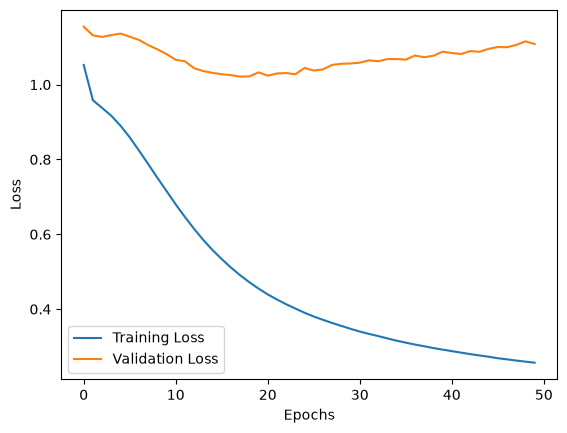

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
R² Score: -0.0999


In [ ]:
# ## Neural Network ##

# # Define the neural network architecture
# nn_model = tf.keras.Sequential([
#     tf.keras.layers.Input(shape=(X_train.shape[1],)),
#     tf.keras.layers.Dense(128, activation='relu'),
#     tf.keras.layers.Dense(64, activation='relu'),
#     tf.keras.layers.Dense(y_train.shape[1])
# ])

# # Compile the model
# nn_model.compile(optimizer='adam', loss='mse', metrics=['mae']) # Using mean squared error (mse) as the loss function

# print(X_train_scaled.shape, y_train_scaled.shape)
# # Fit the model to the training data
# history = nn_model.fit(X_train_scaled, y_train_scaled, epochs=50, batch_size=32, validation_split=0.2, verbose=1)#, callbacks=[early_stopping])

# # Plotting the training and validation loss
# import matplotlib.pyplot as plt

# plt.plot(history.history['loss'], label='Training Loss')
# plt.plot(history.history['val_loss'], label='Validation Loss')
# plt.xlabel('Epochs')
# plt.ylabel('Loss')
# plt.legend()
# plt.show()

# # Save the trained model
# joblib.dump(nn_model, input_dir + 'input/models/NN_trained_model_anom.joblib')

# # Predict on the test set
# y_pred_NN = nn_model.predict(X_test_scaled)

# # Evaluate the model
# r2 = r2_score(y_test_scaled, y_pred_NN)

# print(f"R² Score: {r2:.4f}")

In [ ]:
# def make_abs_df(y_pred, model_name):
#     y_anom = unscale_to_df(
#         y_pred,
#         y_scaler,
#         y_test.index,
#         y_test.columns
#     )

#     y_abs = SeasonalCycleProcessor().add_climatology_back_leadwide(
#         y_anom,
#         scp_y
#     )

#     # copy() defragments; assign() avoids repeated column insertion issues
#     return y_abs.copy().assign(model=model_name)


# y_gp_abs = make_abs_df(y_pred_GP,  "GP")
# y_rf_abs = make_abs_df(y_pred_RFR, "RFR")
# y_nn_abs = make_abs_df(y_pred_NN,  "NN")
# y_xgb_abs = make_abs_df(y_pred_XGB, "XGB")

# df_all = (
#     pd.concat(
#         [y_gp_abs, y_rf_abs, y_nn_abs, y_xgb_abs],
#         axis=0
#     )
#     .reset_index()
#     .rename(columns={"date": "cfs_run", "index": "cfs_run"})
# )

In [ ]:
# # Step 1: Melt into long format
# df_melted = df_all.melt(
#     id_vars=['cfs_run', 'model'],
#     var_name='variable',
#     value_name='value'
# )


In [ ]:
# # Step 2: Split into lake, variable, and month_offset
# split_cols = df_melted['variable'].str.rsplit('_', n=2, expand=True)
# df_melted['lake'] = split_cols[0].str.replace('_target', '', regex=False)
# df_melted['variable'] = split_cols[1]
# df_melted['month_offset'] = split_cols[2].str.replace('mo', '', regex=False).astype(int)

# # Step 3: Compute forecast_month (vectorized, better)
# df_melted['cfs_run'] = pd.to_datetime(df_melted['cfs_run'])
# df_melted['forecast_month'] = (
#     df_melted['cfs_run'].dt.to_period('M') +
#     df_melted['month_offset']
# ).astype(str)


In [ ]:
# df_melted_tmp = df_melted.drop(columns=['month_offset'])

# # Step 4: Pivot with BOTH lake + variable as columns
# df_tidy = df_melted.pivot_table(
#     index=['cfs_run', 'model', 'forecast_month'],
#     columns=['lake', 'variable'],
#     values='value'
# )

# # Flatten MultiIndex columns → "lake_variable"
# df_tidy.columns = [f"{lake}_{var}" for lake, var in df_tidy.columns]

# df_tidy = df_tidy.reset_index()

# # Step 5: Reorder columns
# expected_vars = ["precipitation", "evaporation", "runoff", "nbs"]
# lakes = ['superior', 'michigan-huron', 'erie', 'ontario']

# ordered_feature_cols = [
#     f"{lake}_{var}"
#     for lake in lakes
#     for var in expected_vars
#     if f"{lake}_{var}" in df_tidy.columns
# ]

# cols = ["cfs_run", "forecast_month", "model"] + ordered_feature_cols

# df_final = df_tidy[cols]

# # Convert cfs_run back to YYYYMMDDHH format
# df_final["cfs_run"] = pd.to_datetime(df_final["cfs_run"]).dt.strftime("%Y%m%d%H")

In [ ]:
# # Optionally save the test data
# output_dir = os.path.join(input_dir, "output")
# os.makedirs(output_dir, exist_ok=True)

# df_final.to_csv(
#     os.path.join(output_dir, "CNBS_test_anom.csv"),
#     index=True
# )

In [ ]:
# # 1) standardized -> anomaly units (lead-wide columns already present)
# y_true_anom = unscale_to_df(y_test_scaled, y_scaler, y_test.index, y_test.columns)
# y_pred_anom = unscale_to_df(y_pred_NN,    y_scaler, y_test.index, y_test.columns)

# print("R² (anomaly, lead-wide):", r2_flat(y_true_anom, y_pred_anom))

# # 2) anomaly -> absolute (lead-aware)
# y_true_abs = SeasonalCycleProcessor().add_climatology_back_leadwide(y_true_anom, scp_y)
# y_pred_abs = SeasonalCycleProcessor().add_climatology_back_leadwide(y_pred_anom, scp_y)

# print("R² (absolute, reconstructed):", r2_flat(y_true_abs, y_pred_abs))

# # 3) climatology-only baseline in absolute space (lead-aware!)
# y_clim_abs = SeasonalCycleProcessor().add_climatology_back_leadwide(y_true_anom * 0.0, scp_y)
# print("R² (absolute, climatology-only):", r2_flat(y_true_abs, y_clim_abs))

R² (anomaly, lead-wide): -0.03827122264184868
R² (absolute, reconstructed): 0.6175023366330916
R² (absolute, climatology-only): 0.6312143325986058


Calculate Skill Metrics on the Test Data Set

In [ ]:
# def compute_skill_metrics(
#     model,
#     y_true_std,
#     y_pred_std,
#     y_scaler,
#     *,
#     y_index,
#     y_columns,
#     seasonal_processor=None,
#     by_lead=False,
# ):
#     """
#     Compute skill metrics for lead-wide targets in:
#       (1) anomaly space
#       (2) absolute reconstructed space (adds monthly climatology back; lead-aware)
#       (3) absolute climatology-only baseline (lead-aware)

#     Parameters
#     ----------
#     model : str
#         Model name.

#     y_true_std : np.ndarray
#         True values in standardized space, shape (n_samples, n_targets).

#     y_pred_std : np.ndarray
#         Predicted values in standardized space, shape (n_samples, n_targets).

#     y_scaler : sklearn-like scaler
#         Must implement inverse_transform() mapping standardized -> anomaly units.

#     y_index : pd.DatetimeIndex
#         Index for the target rows (init dates).

#     y_columns : list[str]
#         Target column names, expected to include suffixes like '_mo0'..'_mo11'.

#     seasonal_processor : SeasonalCycleProcessor, optional
#         If provided, must contain `climatology` used to reconstruct absolute values.

#     by_lead : bool
#         If True, adds R² by lead month as columns: R²_mo0 ... R²_mo11
#         (computed in each space where applicable).

#     Returns
#     -------
#     pd.DataFrame
#         One or more rows (one per Space) with metrics.
#         Columns include: Model, Space, RMSE, R², Bias, Std Dev, CRPS (+ optional lead columns)
#     """

#     def to_df(y_std):
#         return pd.DataFrame(
#             y_scaler.inverse_transform(y_std),
#             index=y_index,
#             columns=y_columns
#         )

#     def flat_metrics(y_true_df, y_pred_df):
#         yt = y_true_df.to_numpy().ravel()
#         yp = y_pred_df.to_numpy().ravel()

#         rmse = np.sqrt(mean_squared_error(yt, yp))
#         r2 = r2_score(yt, yp)  # IMPORTANT: consistent space (not standardized)
#         bias = np.mean(yp - yt)
#         std_dev = np.std(yp - yt, ddof=1)
#         crps = np.mean(crps_ensemble(yt, yp[:, None]))  # deterministic CRPS
#         return rmse, r2, bias, std_dev, crps

#     def r2_by_lead(y_true_df, y_pred_df):
#         out = {}
#         for lead in range(12):
#             cols = [c for c in y_true_df.columns if c.endswith(f"_mo{lead}")]
#             if not cols:
#                 continue
#             out[f"R²_mo{lead}"] = r2_score(
#                 y_true_df[cols].to_numpy().ravel(),
#                 y_pred_df[cols].to_numpy().ravel()
#             )
#         return out

#     rows = []

#     # --- (1) anomaly space ---
#     y_true_anom = to_df(y_true_std)
#     y_pred_anom = to_df(y_pred_std)

#     rmse, r2, bias, std_dev, crps = flat_metrics(y_true_anom, y_pred_anom)
#     row = {
#         "Model": model,
#         "Space": "anomaly",
#         "RMSE": round(rmse, 3),
#         "R²": round(r2, 3),
#         "Bias": round(bias, 3),
#         "Std Dev": round(std_dev, 3),
#         "CRPS": round(crps, 3),
#     }
#     if by_lead:
#         row.update({k: round(v, 3) for k, v in r2_by_lead(y_true_anom, y_pred_anom).items()})
#     rows.append(row)

#     # --- (2) absolute reconstructed + (3) climatology-only ---
#     if seasonal_processor is not None:
#         y_true_abs = SeasonalCycleProcessor().add_climatology_back_leadwide(y_true_anom, seasonal_processor)
#         y_pred_abs = SeasonalCycleProcessor().add_climatology_back_leadwide(y_pred_anom, seasonal_processor)

#         rmse, r2, bias, std_dev, crps = flat_metrics(y_true_abs, y_pred_abs)
#         row = {
#             "Model": model,
#             "Space": "absolute_reconstructed",
#             "RMSE": round(rmse, 3),
#             "R²": round(r2, 3),
#             "Bias": round(bias, 3),
#             "Std Dev": round(std_dev, 3),
#             "CRPS": round(crps, 3),
#         }
#         if by_lead:
#             row.update({k: round(v, 3) for k, v in r2_by_lead(y_true_abs, y_pred_abs).items()})
#         rows.append(row)

#         # climatology-only baseline: 0 anomalies + climatology
#         y_clim_abs = SeasonalCycleProcessor().add_climatology_back_leadwide(y_true_anom * 0.0, seasonal_processor)

#         rmse, r2, bias, std_dev, crps = flat_metrics(y_true_abs, y_clim_abs)
#         row = {
#             "Model": model,
#             "Space": "absolute_climatology_only",
#             "RMSE": round(rmse, 3),
#             "R²": round(r2, 3),
#             "Bias": round(bias, 3),
#             "Std Dev": round(std_dev, 3),
#             "CRPS": round(crps, 3),
#         }
#         if by_lead:
#             row.update({k: round(v, 3) for k, v in r2_by_lead(y_true_abs, y_clim_abs).items()})
#         rows.append(row)

#     return pd.DataFrame(rows)

In [ ]:
# skill_GP = compute_skill_metrics(
#     "Gaussian Process",
#     y_test_scaled,
#     y_pred_GP,
#     y_scaler,
#     y_index=y_test.index,
#     y_columns=y_test.columns,
#     seasonal_processor=scp_y,   # important
#     by_lead=True,              # flip to True when you want all the lead times
# )

# skill_RF = compute_skill_metrics(
#     "Random Forest",
#     y_test_scaled,
#     y_pred_RFR,
#     y_scaler,
#     y_index=y_test.index,
#     y_columns=y_test.columns,
#     seasonal_processor=scp_y,   # important
#     by_lead=True,              # flip to True when you want all the lead times
# )

# skill_XGB = compute_skill_metrics(
#     "XG Boost",
#     y_test_scaled,
#     y_pred_XGB,
#     y_scaler,
#     y_index=y_test.index,
#     y_columns=y_test.columns,
#     seasonal_processor=scp_y,   # important
#     by_lead=True,              # flip to True when you want all the lead times
# )

# skill_NN = compute_skill_metrics(
#     "Neural Network",
#     y_test_scaled,
#     y_pred_NN,
#     y_scaler,
#     y_index=y_test.index,
#     y_columns=y_test.columns,
#     seasonal_processor=scp_y,   # important
#     by_lead=True,              # flip to True when you want all the lead times
# )

# results_df = pd.concat([skill_GP, skill_RF, skill_NN, skill_XGB], ignore_index=True)

In [ ]:
# results_df

,Model,Space,RMSE,R²,Bias,Std Dev,CRPS,R²_mo0,R²_mo1,R²_mo2,R²_mo3,R²_mo4,R²_mo5,R²_mo6,R²_mo7,R²_mo8,R²_mo9,R²_mo10,R²_mo11
0,Gaussian Process,anomaly,38.674,0.265,2.788,38.575,22.986,0.318,0.379,0.355,0.353,0.328,0.334,0.346,0.299,0.379,0.403,-0.112,-0.206
1,Gaussian Process,absolute_reconstructed,38.674,0.729,2.788,38.575,22.986,0.749,0.772,0.770,0.774,0.755,0.750,0.754,0.738,0.769,0.777,0.583,0.551
2,Gaussian Process,absolute_climatology_only,45.141,0.631,-1.462,45.120,28.005,0.631,0.632,0.644,0.650,0.635,0.624,0.624,0.625,0.628,0.627,0.625,0.628
3,Random Forest,anomaly,42.181,0.126,0.096,42.183,26.515,0.120,0.144,0.128,0.145,0.175,0.140,0.158,0.165,0.157,0.136,0.031,0.009
4,Random Forest,absolute_reconstructed,42.181,0.678,0.096,42.183,26.515,0.676,0.685,0.690,0.701,0.699,0.677,0.684,0.687,0.686,0.678,0.637,0.631
5,Random Forest,absolute_climatology_only,45.141,0.631,-1.462,45.120,28.005,0.631,0.632,0.644,0.650,0.635,0.624,0.624,0.625,0.628,0.627,0.625,0.628
6,Neural Network,anomaly,45.973,-0.038,-3.164,45.866,28.696,0.074,0.111,0.061,-0.026,0.125,0.152,0.135,0.053,-0.050,-0.069,-0.560,-0.473
7,Neural Network,absolute_reconstructed,45.973,0.618,-3.164,45.866,28.696,0.660,0.673,0.666,0.642,0.681,0.682,0.675,0.645,0.609,0.601,0.415,0.451
8,Neural Network,absolute_climatology_only,45.141,0.631,-1.462,45.120,28.005,0.631,0.632,0.644,0.650,0.635,0.624,0.624,0.625,0.628,0.627,0.625,0.628
9,XG Boost,anomaly,38.650,0.266,1.728,38.613,23.530,0.315,0.332,0.342,0.354,0.327,0.312,0.313,0.300,0.327,0.319,0.024,-0.076


In [ ]:
# # start from results_df (the big table)
# base = results_df[["Model", "Space", "RMSE", "R²", "Bias", "Std Dev", "CRPS"]].copy()

# recon = base[base["Space"] == "absolute_reconstructed"][["Model", "R²", "RMSE"]].rename(
#     columns={"R²": "R²_abs", "RMSE": "RMSE_abs"}
# )
# anom = base[base["Space"] == "anomaly"][["Model", "R²", "RMSE"]].rename(
#     columns={"R²": "R²_anom", "RMSE": "RMSE_anom"}
# )
# clim = base[base["Space"] == "absolute_climatology_only"][["Model", "R²", "RMSE"]].rename(
#     columns={"R²": "R²_clim", "RMSE": "RMSE_clim"}
# )

# summary = (
#     recon.merge(anom, on="Model")
#          .merge(clim, on="Model")
#          .assign(delta_R2=lambda d: d["R²_abs"] - d["R²_clim"])
#          .sort_values("delta_R2", ascending=False)
#          .reset_index(drop=True)
# )

# summary.style.format({
#     "R²_abs": "{:.3f}", "R²_anom": "{:.3f}", "R²_clim": "{:.3f}", "delta_R2": "{:.3f}",
#     "RMSE_abs": "{:.2f}", "RMSE_anom": "{:.2f}", "RMSE_clim": "{:.2f}",
# })

,Model,R²_abs,RMSE_abs,R²_anom,RMSE_anom,R²_clim,RMSE_clim,delta_R2
0,XG Boost,0.730,38.65,0.266,38.65,0.631,45.14,0.099
1,Gaussian Process,0.729,38.67,0.265,38.67,0.631,45.14,0.098
2,Random Forest,0.678,42.18,0.126,42.18,0.631,45.14,0.047
3,Neural Network,0.618,45.97,-0.038,45.97,0.631,45.14,-0.013


In [ ]:
# def plot_styled_table(df):
#     fig, ax = plt.subplots(figsize=(1.8 * len(df.columns), 1 + 0.5 * len(df)))
#     ax.axis('off')

#     table_data = [df.columns.to_list()] + df.round(3).values.tolist()

#     table = ax.table(
#         cellText=table_data,
#         loc='center',
#         cellLoc='center',
#         edges='closed'
#     )

#     ncols = len(df.columns)

#     for (row, col), cell in table.get_celld().items():
#         if row == 0:
#             cell.set_facecolor('#d3d3d3')
#             cell.get_text().set_fontweight('bold')
#         cell.get_text().set_fontsize(11)

#         cell.set_height(0.12)

#         # Wider model column
#         if col == 0:
#             cell.set_width(0.25)
#         else:
#             cell.set_width(0.75 / (ncols - 1))

#     table.auto_set_font_size(False)

#     plt.tight_layout()
#     plt.show()

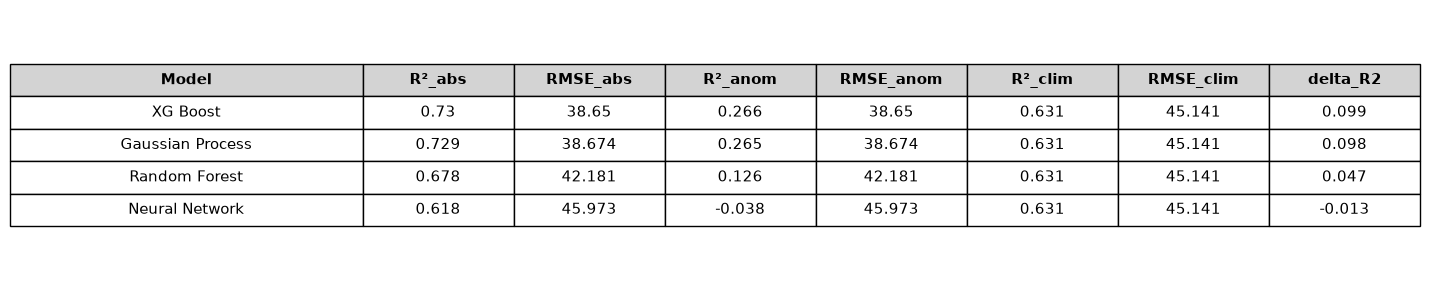

In [ ]:
# plot_styled_table(summary)

In [ ]:
# lead_cols = [c for c in results_df.columns if c.startswith("R²_mo")]

# lead_skill = (
#     results_df[results_df["Space"] == "anomaly"][["Model"] + lead_cols]
#     .melt(id_vars="Model", var_name="lead", value_name="R²")
# )

# lead_skill["lead"] = lead_skill["lead"].str.replace("R²_mo", "").astype(int)
# lead_skill = lead_skill.sort_values(["Model", "lead"])

#### Plot anomaly skill by lead month and method

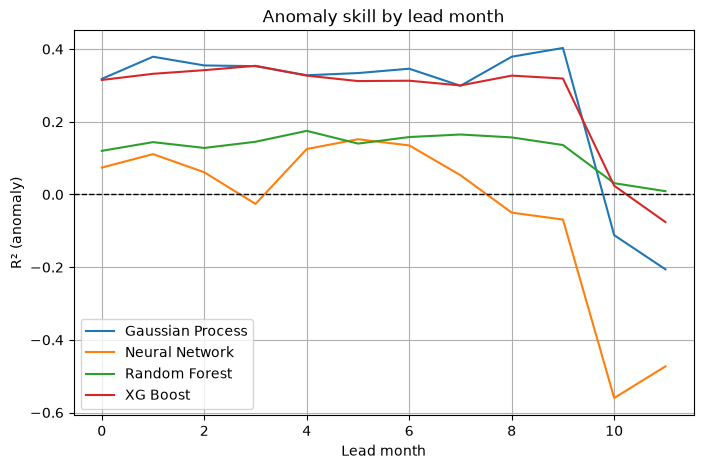

In [ ]:
# plt.figure(figsize=(8,5))
# for model, g in lead_skill.groupby("Model"):
#     plt.plot(g["lead"], g["R²"], label=model)

# plt.axhline(0, linewidth=1, color='black', linestyle='--')
# plt.xlabel("Lead month")
# plt.ylabel("R² (anomaly)")
# plt.title("Anomaly skill by lead month")
# plt.legend()
# plt.grid(True)
# plt.show()

### Plot skill score relative to climatology 

Current setup below will just run this analysis for the last model to be tested, so the results don't reflect the "best" modeling efforts necessarily

In [ ]:
# summary = summary.assign(
#     SkillScore=lambda d: 1 - d["RMSE_abs"] / d["RMSE_clim"]
# )

# summary.style.format({
#     "R²_abs": "{:.3f}",
#     "R²_clim": "{:.3f}",
#     "delta_R2": "{:.3f}",
#     "RMSE_abs": "{:.2f}",
#     "RMSE_clim": "{:.2f}",
#     "SkillScore": "{:.3f}"
# })

,Model,R²_abs,RMSE_abs,R²_anom,RMSE_anom,R²_clim,RMSE_clim,delta_R2,SkillScore
0,XG Boost,0.730,38.65,0.266000,38.650000,0.631,45.14,0.099,0.144
1,Gaussian Process,0.729,38.67,0.265000,38.674000,0.631,45.14,0.098,0.143
2,Random Forest,0.678,42.18,0.126000,42.181000,0.631,45.14,0.047,0.066
3,Neural Network,0.618,45.97,-0.038000,45.973000,0.631,45.14,-0.013,-0.018


In [ ]:
# def rmse(a, b):
#     return np.sqrt(np.mean((a - b) ** 2))

# def rmse_by_lead(y_true_df, y_pred_df):
#     results = {}
#     for lead in range(12):
#         cols = [c for c in y_true_df.columns if c.endswith(f"_mo{lead}")]
#         if not cols:
#             continue
        
#         yt = y_true_df[cols].to_numpy().ravel()
#         yp = y_pred_df[cols].to_numpy().ravel()
        
#         results[lead] = rmse(yt, yp)
        
#     return results

In [ ]:
# rmse_model = rmse_by_lead(y_true_abs, y_pred_abs)
# rmse_clim  = rmse_by_lead(y_true_abs, y_clim_abs)

# skill_by_lead = {
#     lead: 1 - rmse_model[lead] / rmse_clim[lead]
#     for lead in rmse_model
# }

# skill_by_lead_df = (
#     pd.DataFrame({
#         "lead": list(skill_by_lead.keys()),
#         "SkillScore": list(skill_by_lead.values())
#     })
#     .sort_values("lead")
# )

# skill_by_lead_df

,lead,SkillScore
0,0,0.038850
1,1,0.058229
2,2,0.031687
3,3,-0.012140
4,4,0.065356
5,5,0.079550
6,6,0.070736
7,7,0.027494
8,8,-0.024244
9,9,-0.033941


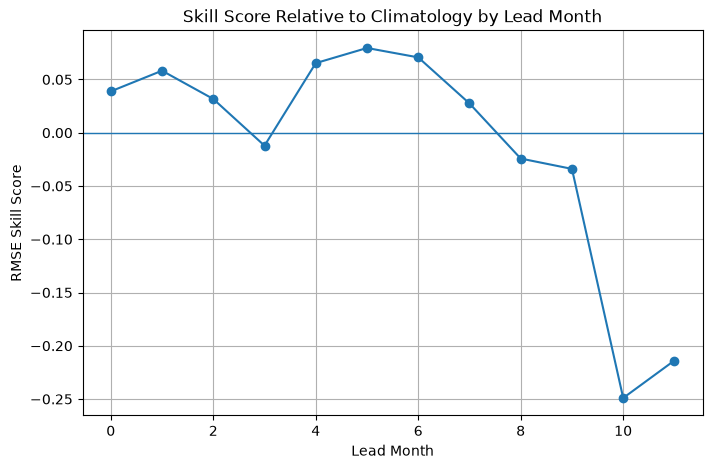

In [ ]:
# plt.figure(figsize=(8,5))
# plt.plot(skill_by_lead_df["lead"], skill_by_lead_df["SkillScore"], marker="o")
# plt.axhline(0, linewidth=1)
# plt.xlabel("Lead Month")
# plt.ylabel("RMSE Skill Score")
# plt.title("Skill Score Relative to Climatology by Lead Month")
# plt.grid(True)
# plt.show()

In [ ]:
# targets

,superior_target_evaporation,superior_target_precipitation,superior_target_runoff,superior_target_nbs,michigan-huron_target_evaporation,michigan-huron_target_precipitation,michigan-huron_target_runoff,michigan-huron_target_nbs,erie_target_evaporation,erie_target_precipitation,erie_target_runoff,erie_target_nbs,ontario_target_evaporation,ontario_target_precipitation,ontario_target_runoff,ontario_target_nbs
date,,,,,,,,,,,,,,,,
1950-01-01,125.357918,88.75,33.2,14.026862,95.709892,91.03,104.7,94.677343,38.810083,166.00,238.30,550.186890,75.883804,111.8,271.8,375.028505
1950-02-01,70.413371,36.98,25.5,-8.961299,59.667369,64.88,65.8,57.923217,40.703714,94.80,136.20,258.878682,77.272852,88.8,147.1,188.013699
1950-03-01,42.505142,62.08,31.0,49.607194,36.461632,77.05,81.9,124.142145,26.439582,97.00,162.60,427.763105,43.856645,71.4,196.6,323.419078
1950-04-01,25.310708,89.29,48.1,142.365472,23.005784,84.70,125.2,200.438931,16.345690,101.30,161.40,367.968263,17.753245,60.1,283.2,529.412835
1950-05-01,-8.965747,147.60,115.5,340.750102,0.003105,55.79,110.9,130.425081,10.834650,47.30,68.10,115.222385,2.194818,52.9,117.2,182.353310
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-08-01,5.267900,73.93,36.0,83.476933,41.785871,84.30,33.5,38.130921,112.690526,101.69,20.42,24.484757,69.512130,84.0,40.7,22.364085
2022-09-01,50.655000,104.23,36.5,83.763871,76.020764,71.23,32.2,-21.176080,161.345409,88.97,25.36,-90.598246,88.009890,65.4,53.8,-39.955686
2022-10-01,81.158000,63.07,41.3,13.684743,87.836585,72.61,37.1,-2.383183,177.551294,50.74,17.61,-154.109940,84.626460,32.1,45.6,-46.448485


# Integrated NBS skill

Trying out 1, 3, and 6 month integrated NBS skill

In [ ]:
# def compute_integrated_skill(
#     y_true_df,
#     y_pred_df,
#     variable="superior_target_nbs",
#     window=3
# ):
#     """
#     Compute skill on integrated (rolling-sum) lead windows.

#     Parameters
#     ----------
#     y_true_df : pd.DataFrame
#         Reconstructed absolute true values (with _mo{k} columns)

#     y_pred_df : pd.DataFrame
#         Reconstructed absolute predicted values

#     variable : str
#         Base variable name (e.g., 'superior_target_nbs')

#     window : int
#         Integration window (1, 3, 6 months)

#     Returns
#     -------
#     float
#         R² for integrated values
#     """

#     lead_cols = [
#         f"{variable}_mo{k}" for k in range(12)
#         if f"{variable}_mo{k}" in y_true_df.columns
#     ]

#     y_true_vals = y_true_df[lead_cols].values
#     y_pred_vals = y_pred_df[lead_cols].values

#     # rolling integration across lead axis
#     integrated_true = []
#     integrated_pred = []

#     for start in range(len(lead_cols) - window + 1):
#         integrated_true.append(
#             y_true_vals[:, start:start+window].sum(axis=1)
#         )
#         integrated_pred.append(
#             y_pred_vals[:, start:start+window].sum(axis=1)
#         )

#     integrated_true = np.concatenate(integrated_true)
#     integrated_pred = np.concatenate(integrated_pred)

#     return r2_score(integrated_true, integrated_pred)

In [ ]:
# r2_1m = compute_integrated_skill(y_true_abs, y_pred_abs, window=1)
# r2_3m = compute_integrated_skill(y_true_abs, y_pred_abs, window=3)
# r2_6m = compute_integrated_skill(y_true_abs, y_pred_abs, window=6)

# print("1-month:", r2_1m)
# print("3-month:", r2_3m)
# print("6-month:", r2_6m)

1-month: 0.5610395529294991
3-month: 0.6357410373004577
6-month: 0.5006260696206013


In [ ]:
# def compute_integrated_metrics(
#     y_true_df,
#     y_pred_df,
#     y_clim_df,
#     variable="superior_target_nbs",
#     window=3
# ):
#     """
#     Compute integrated metrics for model and climatology baseline.

#     Returns:
#         dict with:
#             r2_model
#             r2_climatology
#             skill_score
#     """

#     lead_cols = [
#         f"{variable}_mo{k}" for k in range(12)
#         if f"{variable}_mo{k}" in y_true_df.columns
#     ]

#     y_true_vals = y_true_df[lead_cols].values
#     y_pred_vals = y_pred_df[lead_cols].values
#     y_clim_vals = y_clim_df[lead_cols].values

#     integrated_true = []
#     integrated_pred = []
#     integrated_clim = []

#     for start in range(len(lead_cols) - window + 1):
#         integrated_true.append(y_true_vals[:, start:start+window].sum(axis=1))
#         integrated_pred.append(y_pred_vals[:, start:start+window].sum(axis=1))
#         integrated_clim.append(y_clim_vals[:, start:start+window].sum(axis=1))

#     integrated_true = np.concatenate(integrated_true)
#     integrated_pred = np.concatenate(integrated_pred)
#     integrated_clim = np.concatenate(integrated_clim)

#     r2_model = r2_score(integrated_true, integrated_pred)
#     r2_clim = r2_score(integrated_true, integrated_clim)

#     mse_model = mean_squared_error(integrated_true, integrated_pred)
#     mse_clim = mean_squared_error(integrated_true, integrated_clim)

#     skill = 1 - (mse_model / mse_clim)

#     return {
#         "R2_model": r2_model,
#         "R2_climatology": r2_clim,
#         "Skill_vs_climatology": skill
#     }

In [ ]:
# for w in [1, 3, 6]:
#     metrics = compute_integrated_metrics(
#         y_true_abs,
#         y_pred_abs,
#         y_clim_abs,
#         variable="superior_target_nbs",
#         window=w
#     )
#     print(f"\n{w}-month integration")
#     print(metrics)


1-month integration
{'R2_model': 0.5610395529294991, 'R2_climatology': 0.5996130134252748, 'Skill_vs_climatology': -0.09634044509230466}

3-month integration
{'R2_model': 0.6357410373004577, 'R2_climatology': 0.7099203553596614, 'Skill_vs_climatology': -0.2557205216904359}

6-month integration
{'R2_model': 0.5006260696206013, 'R2_climatology': 0.6068860640728388, 'Skill_vs_climatology': -0.2703033007507678}


# Exploring integrated NBS Options

In [ ]:
# def summarize_integrated_skill(
#     y_true_abs,
#     y_clim_abs,
#     model_predictions,
#     variable="superior_target_nbs",
#     windows=(1, 3, 6)
# ):
#     """
#     Parameters
#     ----------
#     model_predictions : dict
#         {"Model Name": y_pred_abs_df}
#     """

#     rows = []

#     for model_name, y_pred_abs in model_predictions.items():
#         for w in windows:

#             metrics = compute_integrated_metrics(
#                 y_true_abs,
#                 y_pred_abs,
#                 y_clim_abs,
#                 variable=variable,
#                 window=w
#             )

#             rows.append({
#                 "Model": model_name,
#                 "Window (months)": w,
#                 "R2_model": round(metrics["R2_model"], 3),
#                 "R2_climatology": round(metrics["R2_climatology"], 3),
#                 "Skill_vs_climatology": round(metrics["Skill_vs_climatology"], 3)
#             })

#     return pd.DataFrame(rows)

In [ ]:
# def build_eval_frames(y_test_scaled, y_pred_scaled, y_scaler, y_index, y_columns, scp_y):
#     """
#     Build evaluation DataFrames in three spaces:
#       - anomaly (units after inverse StandardScaler)
#       - absolute reconstructed (lead-aware climatology added back)
#       - absolute climatology-only baseline (lead-aware)

#     Returns
#     -------
#     dict with keys: 'anom', 'abs', 'clim_abs'
#       each value is a pd.DataFrame shaped like (n_times, n_targets)
#     """
#     # 1) standardized -> anomaly units
#     y_true_anom = unscale_to_df(y_test_scaled, y_scaler, y_index, y_columns)
#     y_pred_anom = unscale_to_df(y_pred_scaled, y_scaler, y_index, y_columns)

#     # 2) anomaly -> absolute (lead-aware)
#     y_true_abs = SeasonalCycleProcessor().add_climatology_back_leadwide(y_true_anom, scp_y)
#     y_pred_abs = SeasonalCycleProcessor().add_climatology_back_leadwide(y_pred_anom, scp_y)

#     # 3) climatology-only baseline
#     y_clim_abs = SeasonalCycleProcessor().add_climatology_back_leadwide(y_true_anom * 0.0, scp_y)

#     return {
#         "true_anom": y_true_anom,
#         "pred_anom": y_pred_anom,
#         "true_abs": y_true_abs,
#         "pred_abs": y_pred_abs,
#         "clim_abs": y_clim_abs,
#     }

In [ ]:
# frames_GP = build_eval_frames(y_test_scaled, y_pred_GP,  y_scaler, y_test.index, y_test.columns, scp_y)
# frames_RF = build_eval_frames(y_test_scaled, y_pred_RFR, y_scaler, y_test.index, y_test.columns, scp_y)
# frames_XGB = build_eval_frames(y_test_scaled, y_pred_XGB, y_scaler, y_test.index, y_test.columns, scp_y)
# frames_NN = build_eval_frames(y_test_scaled, y_pred_NN,  y_scaler, y_test.index, y_test.columns, scp_y)

In [ ]:
# def integrated_summary_for_models(frames_by_model, variable, windows=(1,3,6)):
#     rows = []
#     for model_name, fr in frames_by_model.items():
#         for w in windows:
#             m = compute_integrated_metrics(
#                 fr["true_abs"],
#                 fr["pred_abs"],
#                 fr["clim_abs"],
#                 variable=variable,
#                 window=w
#             )
#             rows.append({
#                 "Model": model_name,
#                 "Window": w,
#                 "R2_model": round(m["R2_model"], 3),
#                 "R2_clim": round(m["R2_climatology"], 3),
#                 "Skill": round(m["Skill_vs_climatology"], 3),
#             })
#     return pd.DataFrame(rows)

# frames_by_model = {
#     "Gaussian Process": frames_GP,
#     "Random Forest": frames_RF,
#     "XGBoost": frames_XGB,
#     "Neural Network": frames_NN,
# }

# integrated_df = integrated_summary_for_models(
#     frames_by_model,
#     variable="superior_target_nbs",
#     windows=(1,3,6)
# )

# integrated_df

,Model,Window,R2_model,R2_clim,Skill
0,Gaussian Process,1,0.795,0.600,0.488
1,Gaussian Process,3,0.885,0.710,0.603
2,Gaussian Process,6,0.870,0.607,0.668
3,Random Forest,1,0.638,0.600,0.096
4,Random Forest,3,0.761,0.710,0.176
5,Random Forest,6,0.712,0.607,0.266
6,XGBoost,1,0.748,0.600,0.370
7,XGBoost,3,0.837,0.710,0.437
8,XGBoost,6,0.782,0.607,0.446
9,Neural Network,1,0.561,0.600,-0.096


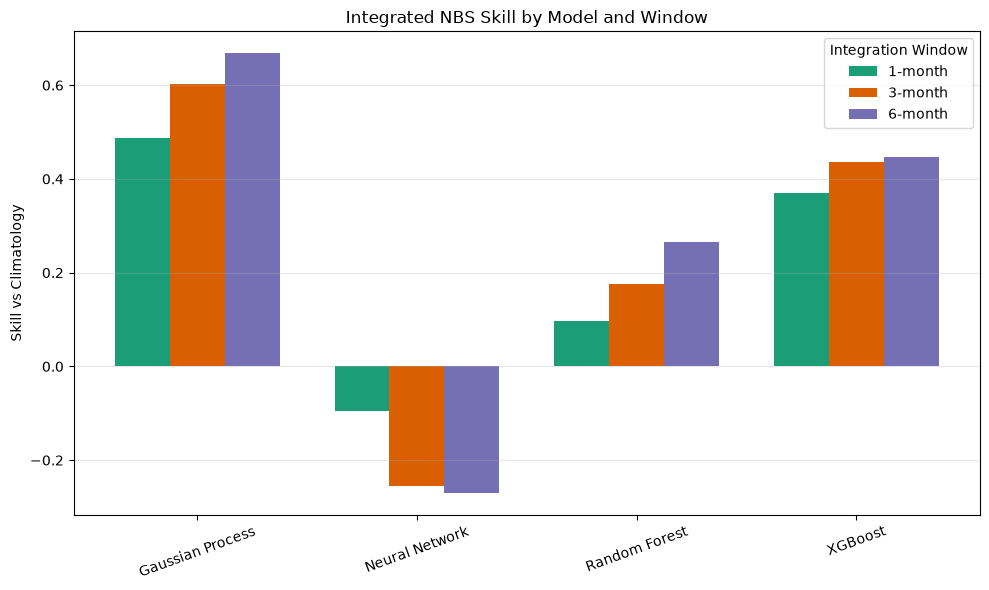

In [ ]:
# skill_pivot = integrated_df.pivot(
#     index="Model",
#     columns="Window",
#     values="Skill"
# ).sort_index()

# models = skill_pivot.index
# windows = skill_pivot.columns

# colors = ["#1b9e77", "#d95f02", "#7570b3"]  # Dark2

# x = np.arange(len(models))
# width = 0.25

# fig, ax = plt.subplots(figsize=(10, 6))

# for i, w in enumerate(windows):
#     ax.bar(
#         x + i*width - width,
#         skill_pivot[w],
#         width,
#         label=f"{w}-month",
#         color=colors[i]
#     )

# ax.set_xticks(x)
# ax.set_xticklabels(models, rotation=20)
# ax.set_ylabel("Skill vs Climatology")
# ax.set_title("Integrated NBS Skill by Model and Window")
# ax.legend(title="Integration Window")
# ax.grid(axis='y', alpha=0.3)

# plt.tight_layout()
# plt.show()

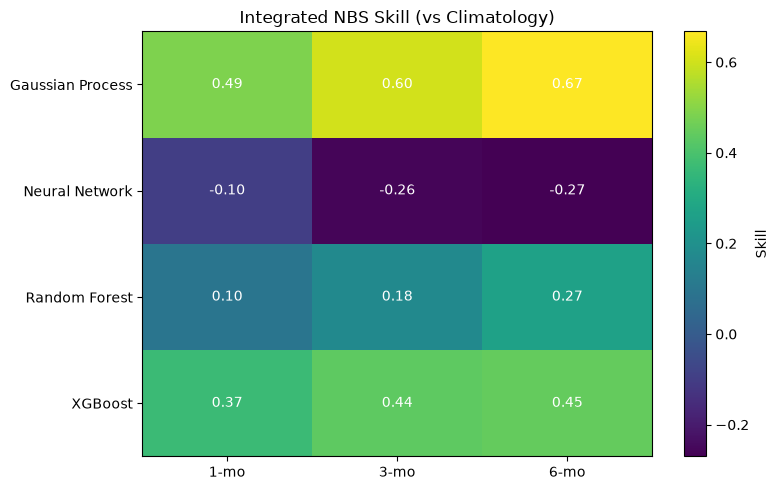

In [ ]:
# fig, ax = plt.subplots(figsize=(8, 5))

# c = ax.imshow(skill_pivot.values, aspect='auto')

# ax.set_xticks(range(len(windows)))
# ax.set_xticklabels([f"{w}-mo" for w in windows])
# ax.set_yticks(range(len(models)))
# ax.set_yticklabels(models)

# ax.set_title("Integrated NBS Skill (vs Climatology)")
# plt.colorbar(c, label="Skill")

# # Annotate cells
# for i in range(len(models)):
#     for j in range(len(windows)):
#         ax.text(j, i, f"{skill_pivot.values[i, j]:.2f}",
#                 ha="center", va="center", color="white")

# plt.tight_layout()
# plt.show()

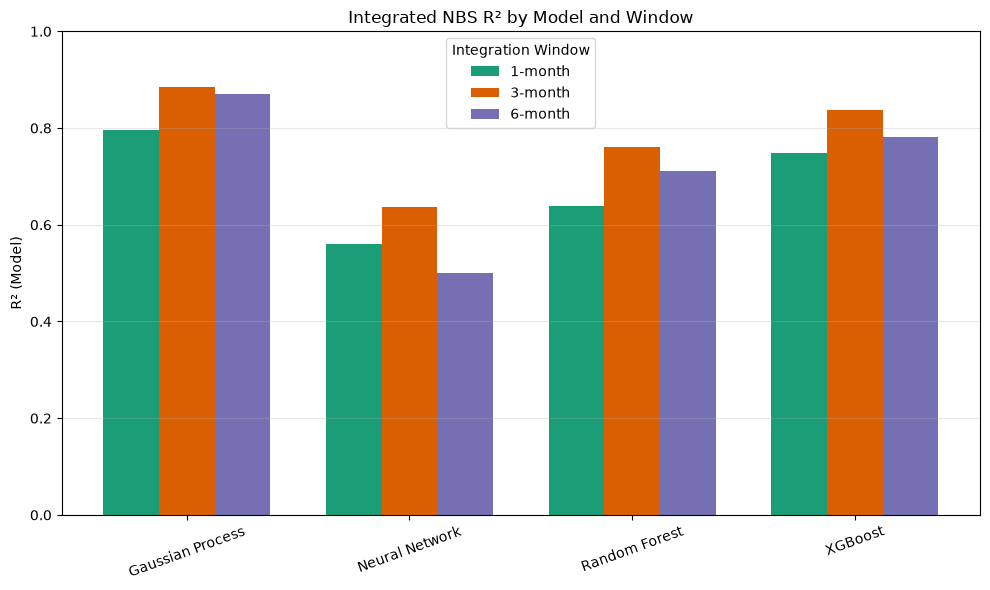

In [ ]:
# import matplotlib.pyplot as plt
# import numpy as np

# r2_model_pivot = integrated_df.pivot(
#     index="Model",
#     columns="Window",
#     values="R2_model"
# ).sort_index()

# models = r2_model_pivot.index
# windows = r2_model_pivot.columns

# x = np.arange(len(models))
# width = 0.25

# fig, ax = plt.subplots(figsize=(10, 6))

# for i, w in enumerate(windows):
#     ax.bar(
#         x + i*width - width,
#         r2_model_pivot[w],
#         width,
#         label=f"{w}-month",
#         color=colors[i]
#     )

# ax.set_xticks(x)
# ax.set_xticklabels(models, rotation=20)
# ax.set_ylabel("R² (Model)")
# ax.set_title("Integrated NBS R² by Model and Window")
# ax.set_ylim(0, 1)
# ax.legend(title="Integration Window")
# ax.grid(axis='y', alpha=0.3)

# plt.tight_layout()
# plt.show()

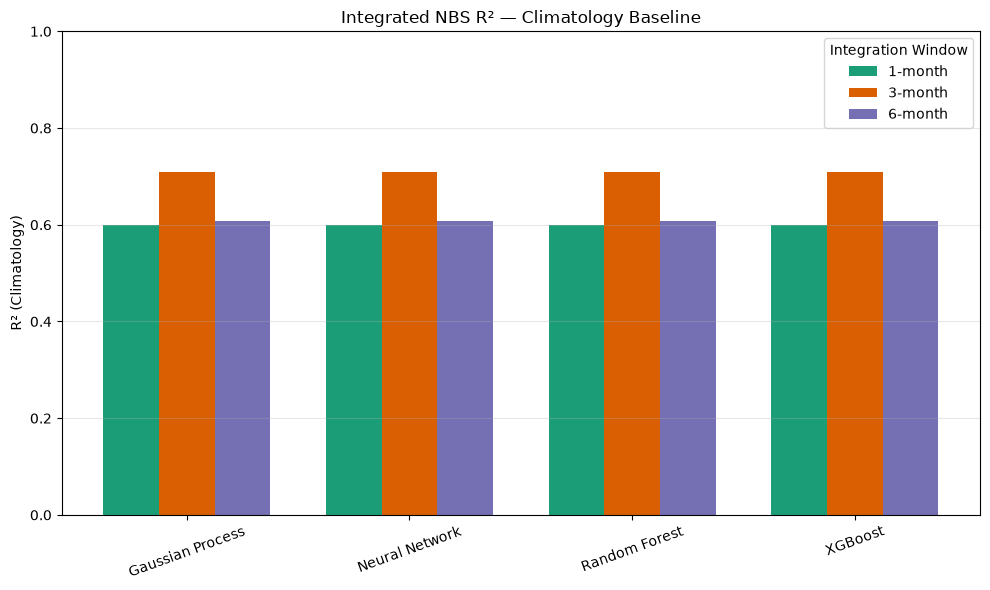

In [ ]:
# r2_clim_pivot = integrated_df.pivot(
#     index="Model",
#     columns="Window",
#     values="R2_clim"
# ).sort_index()

# models = r2_clim_pivot.index
# windows = r2_clim_pivot.columns

# x = np.arange(len(models))
# width = 0.25

# fig, ax = plt.subplots(figsize=(10, 6))

# for i, w in enumerate(windows):
#     ax.bar(
#         x + i*width - width,
#         r2_clim_pivot[w],
#         width,
#         label=f"{w}-month",
#         color=colors[i]
#     )

# ax.set_xticks(x)
# ax.set_xticklabels(models, rotation=20)
# ax.set_ylabel("R² (Climatology)")
# ax.set_title("Integrated NBS R² — Climatology Baseline")
# ax.set_ylim(0, 1)
# ax.legend(title="Integration Window")
# ax.grid(axis='y', alpha=0.3)

# plt.tight_layout()
# plt.show()

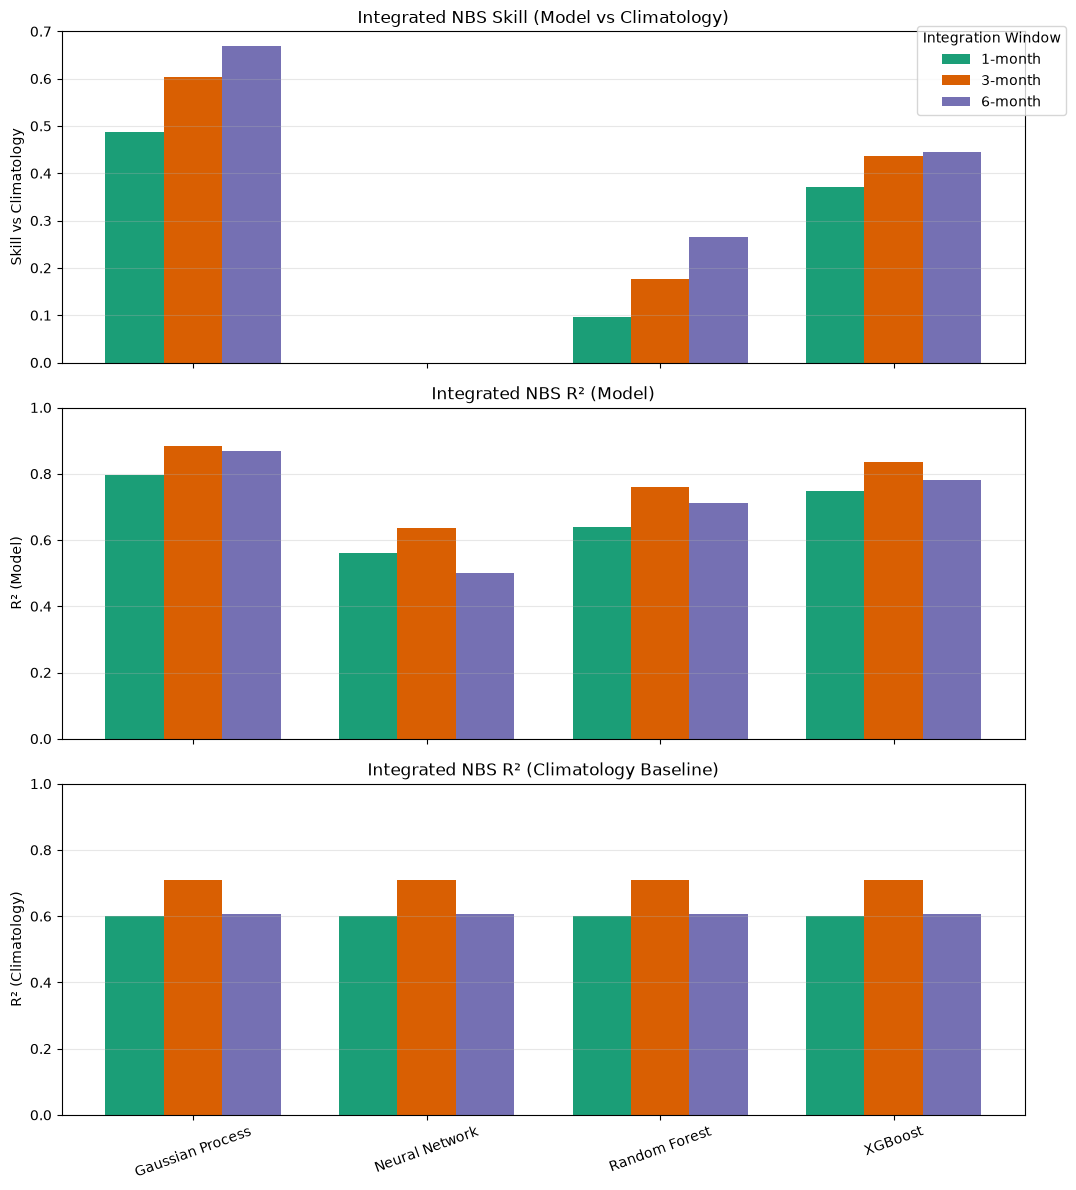

In [ ]:
# import matplotlib.pyplot as plt
# import numpy as np

# colors = ["#1b9e77", "#d95f02", "#7570b3"]  # ColorBrewer Dark2 (colorblind-friendly)

# def plot_grouped_bars(ax, pivot_df, ylabel, title, colors, ylim=(0, 1)):
#     models = pivot_df.index
#     windows = pivot_df.columns
#     x = np.arange(len(models))
#     width = 0.25

#     for i, w in enumerate(windows):
#         ax.bar(
#             x + i*width - width,
#             pivot_df[w].values,
#             width,
#             label=f"{w}-month",
#             color=colors[i]
#         )

#     ax.set_ylabel(ylabel)
#     ax.set_title(title)
#     ax.set_ylim(*ylim)
#     ax.grid(axis="y", alpha=0.3)
#     ax.set_xticks(x)
#     ax.set_xticklabels(models, rotation=20)

# # Pivot tables
# skill_pivot = integrated_df.pivot(index="Model", columns="Window", values="Skill").sort_index()
# r2_model_pivot = integrated_df.pivot(index="Model", columns="Window", values="R2_model").sort_index()
# r2_clim_pivot  = integrated_df.pivot(index="Model", columns="Window", values="R2_clim").sort_index()

# # Create stacked figure
# fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(11, 12), sharex=True)

# plot_grouped_bars(
#     axes[0], skill_pivot,
#     ylabel="Skill vs Climatology",
#     title="Integrated NBS Skill (Model vs Climatology)",
#     colors=colors,
#     ylim=(0, 0.7)  # skill is usually within [-inf, 1], but your range is positive and < 0.7
# )

# plot_grouped_bars(
#     axes[1], r2_model_pivot,
#     ylabel="R² (Model)",
#     title="Integrated NBS R² (Model)",
#     colors=colors,
#     ylim=(0, 1)
# )

# plot_grouped_bars(
#     axes[2], r2_clim_pivot,
#     ylabel="R² (Climatology)",
#     title="Integrated NBS R² (Climatology Baseline)",
#     colors=colors,
#     ylim=(0, 1)
# )

# # Put one legend for the whole figure
# handles, labels = axes[0].get_legend_handles_labels()
# fig.legend(handles, labels, title="Integration Window", loc="upper right", bbox_to_anchor=(0.98, 0.98))

# plt.tight_layout(rect=[0, 0, 0.95, 1])  # leave space for legend
# plt.show()